In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('../Data/data_withAI.csv')

print(df.info())
display(df.describe().round(2))

sns.set_theme(style="whitegrid")

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_kalimat          450 non-null    int64  
 1   bahasa              450 non-null    str    
 2   model               450 non-null    str    
 3   panjang_kata_input  450 non-null    int64  
 4   token_input         450 non-null    int64  
 5   token_output        450 non-null    int64  
 6   latensi             450 non-null    float64
dtypes: float64(1), int64(4), str(2)
memory usage: 24.7 KB
None


,id_kalimat,panjang_kata_input,token_input,token_output,latensi
count,450.00,450.00,450.00,450.00,450.00
mean,25.50,17.59,60.01,65.82,1.88
std,14.45,9.04,18.49,21.36,0.56
min,1.00,9.00,33.00,13.00,0.32
25%,13.00,11.00,48.00,53.00,1.53
50%,25.50,14.00,55.00,63.00,1.82
75%,38.00,21.00,67.00,75.75,2.21
max,50.00,45.00,136.00,207.00,5.23


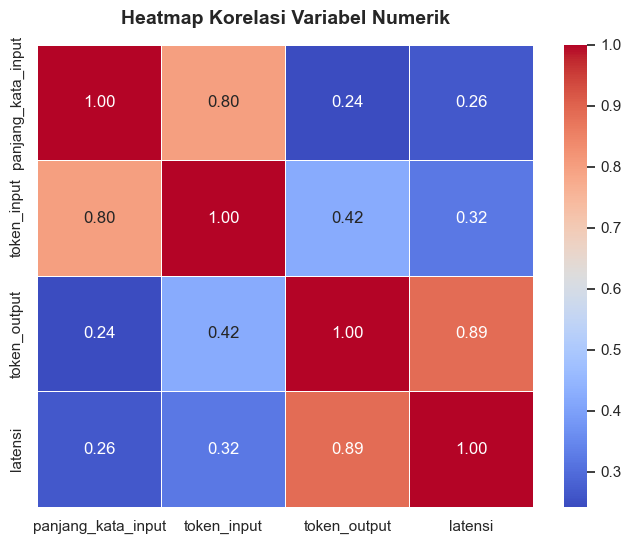

In [2]:
plt.figure(figsize=(8, 6))
kolom_numerik = ['panjang_kata_input', 'token_input', 'token_output', 'latensi']
matriks_korelasi = df[kolom_numerik].corr()

sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=14, fontweight='bold', pad=15)
plt.show()

/var/folders/2k/9v42dhzd2rdg1nkfsqt49skw0000gn/T/ipykernel_41728/1280890949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='bahasa', y='token_output', palette='viridis', inner='quartile')


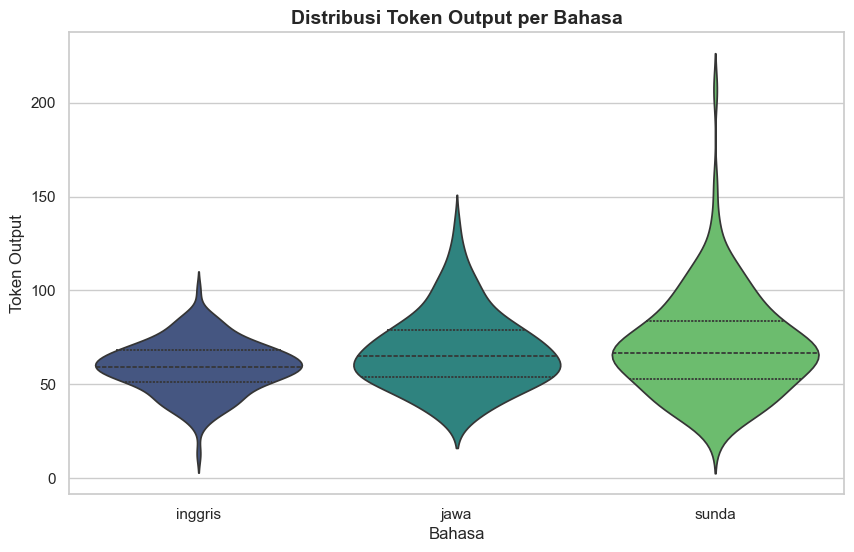

In [3]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='bahasa', y='token_output', palette='viridis', inner='quartile')
plt.title('Distribusi Token Output per Bahasa', fontsize=14, fontweight='bold')
plt.xlabel('Bahasa')
plt.ylabel('Token Output')
plt.show()

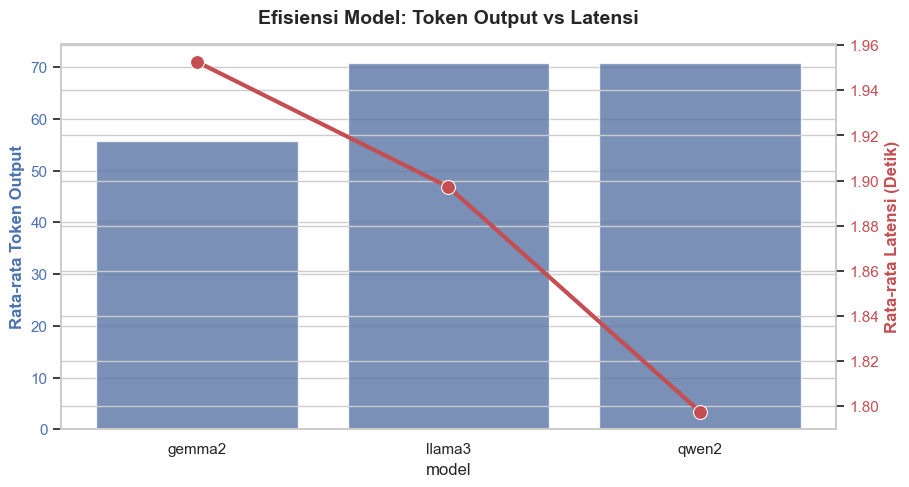

In [4]:
rata_model = df.groupby('model')[['token_output', 'latensi']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=rata_model, x='model', y='token_output', ax=ax1, color='#4c72b0', alpha=0.8)
ax1.set_ylabel('Rata-rata Token Output', color='#4c72b0', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4c72b0')
ax2 = ax1.twinx()
sns.lineplot(data=rata_model, x='model', y='latensi', ax=ax2, color='#c44e52', marker='o', linewidth=3, markersize=10)
ax2.set_ylabel('Rata-rata Latensi (Detik)', color='#c44e52', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#c44e52')

plt.title('Efisiensi Model: Token Output vs Latensi', fontsize=14, fontweight='bold', pad=15)
plt.show()

In [5]:
fig = px.scatter(
    df, 
    x='token_input', 
    y='token_output', 
    color='bahasa',
    symbol='model',
    hover_data=['id_kalimat', 'panjang_kata_input', 'latensi'],
    title='Sebaran Token Input vs Output Berdasarkan Bahasa & Model',
    labels={'token_input': 'Jumlah Token Input', 'token_output': 'Jumlah Token Output'},
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey')
)

fig.show()

/var/folders/2k/9v42dhzd2rdg1nkfsqt49skw0000gn/T/ipykernel_41728/1714515549.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bahasa', y='token_output', ax=axes[1], palette='Set2')
/var/folders/2k/9v42dhzd2rdg1nkfsqt49skw0000gn/T/ipykernel_41728/1714515549.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model', y='token_output', ax=axes[2], palette='pastel')


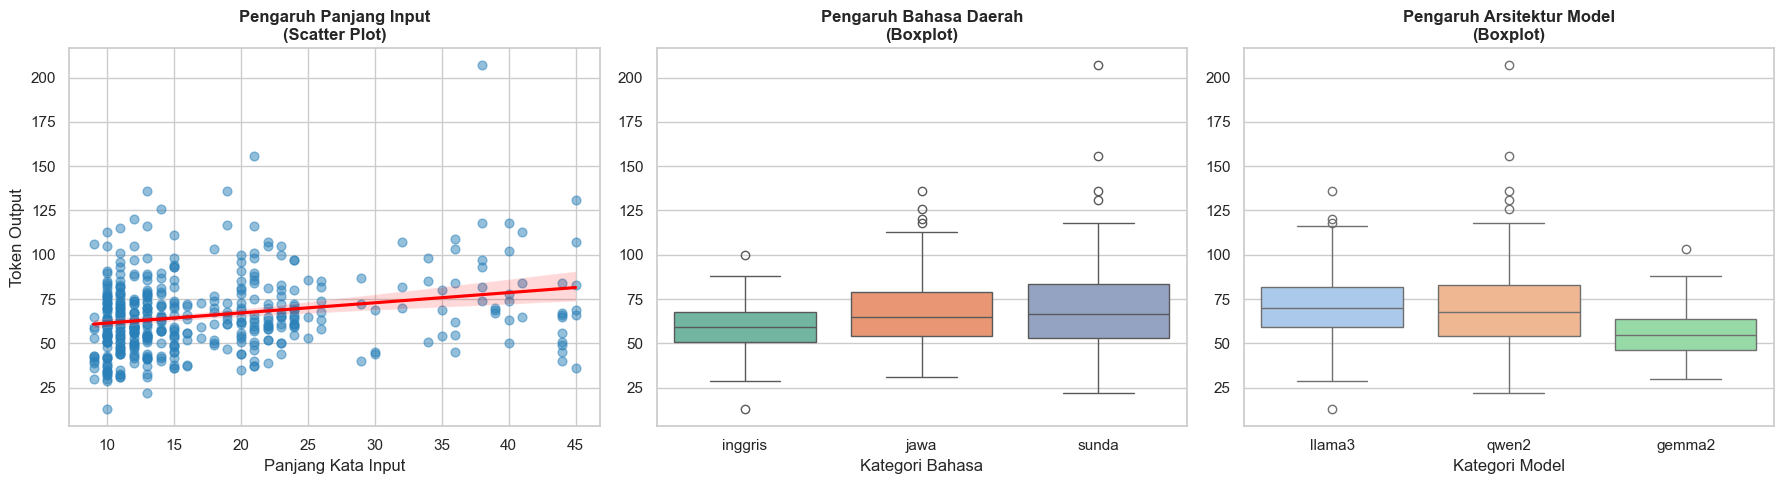

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=df, x='panjang_kata_input', y='token_output', ax=axes[0], 
            color='#2980b9', scatter_kws={'alpha':0.5, 's':40}, line_kws={'color':'red'})
axes[0].set_title('Pengaruh Panjang Input\n(Scatter Plot)', fontweight='bold')
axes[0].set_xlabel('Panjang Kata Input')
axes[0].set_ylabel('Token Output')

sns.boxplot(data=df, x='bahasa', y='token_output', ax=axes[1], palette='Set2')
axes[1].set_title('Pengaruh Bahasa Daerah\n(Boxplot)', fontweight='bold')
axes[1].set_xlabel('Kategori Bahasa')
axes[1].set_ylabel('') 

sns.boxplot(data=df, x='model', y='token_output', ax=axes[2], palette='pastel')
axes[2].set_title('Pengaruh Arsitektur Model\n(Boxplot)', fontweight='bold')
axes[2].set_xlabel('Kategori Model')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()